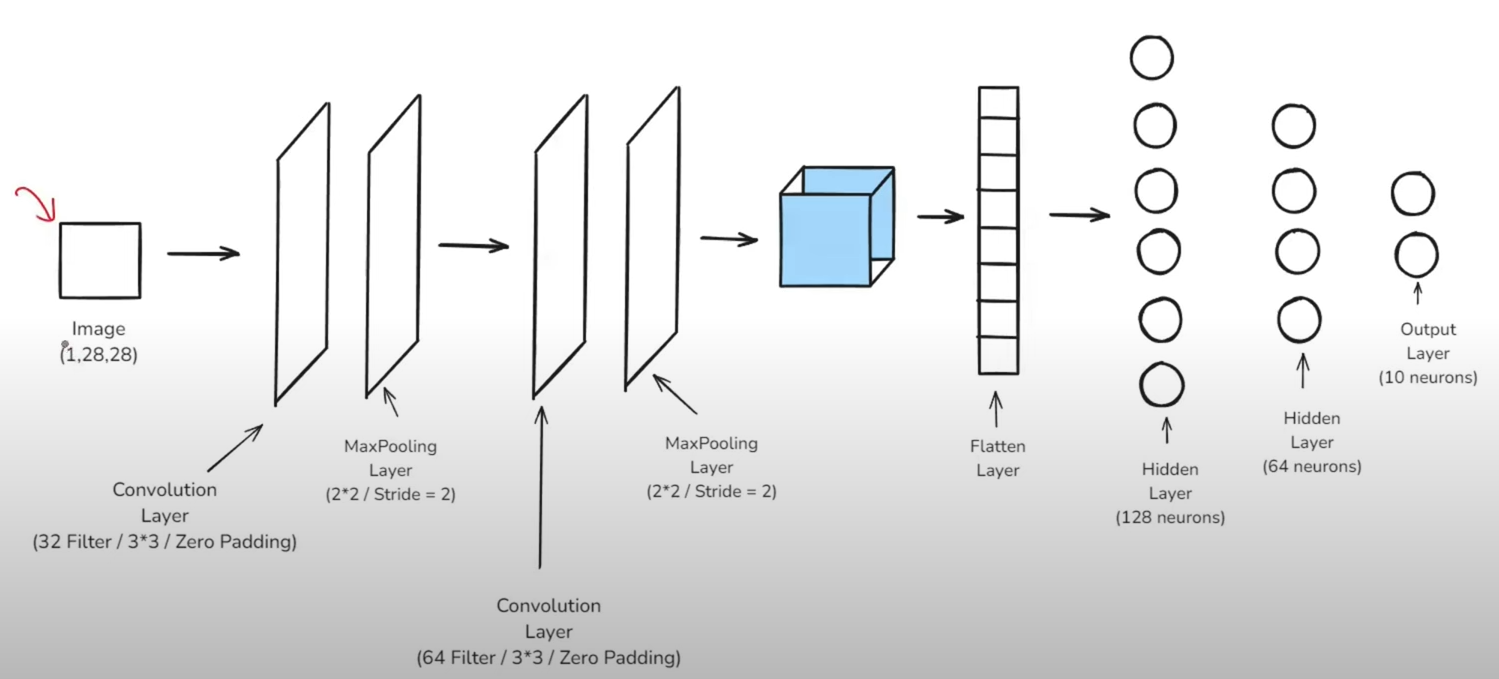

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# Set Manual Seed for Reproducibility
torch.manual_seed(42)

In [4]:
df = pd.read_csv("data/fmnist_small.csv")

In [5]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


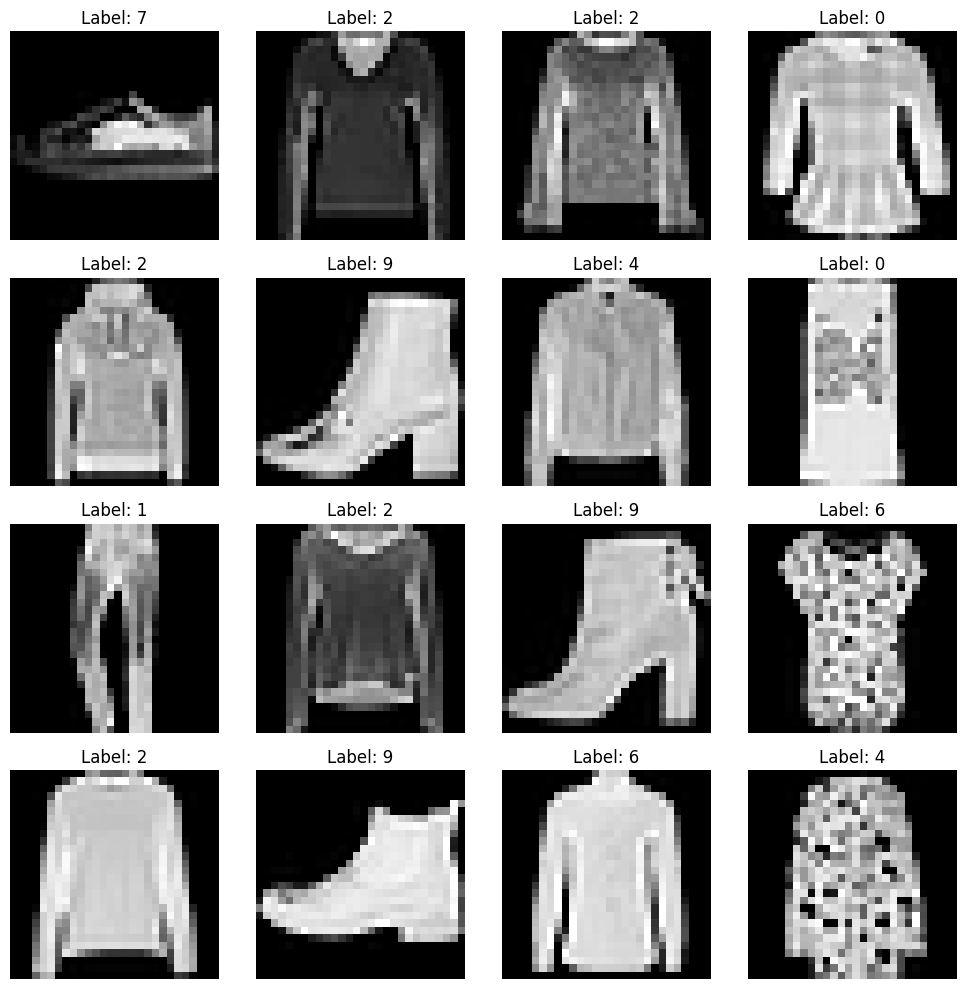

In [6]:
# Display 9 random images from the dataset
# Create a figure with 4x4 subplots
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
# Flatten the axes array for easy iteration
axes = axes.flatten()
# Randomly select 16 indices
random_indices = df.sample(16).index
# Loop through the random indices and plot the images
for i, idx in enumerate(random_indices):
    # Get the image data and label
    image_data = df.iloc[idx, 1:].values.reshape(28, 28)
    label = df.iloc[idx, 0]
    # Plot the image
    axes[i].imshow(image_data, cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')  # Hide the axes
# Hide the remaining axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Split the dataset into features and labels
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Normalize the data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [35]:
# create a custom dataset class
class FashionMNISTDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32).reshape(1, 28, 28)  # Add channel dimension
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label
# Create datasets
train_dataset = FashionMNISTDataset(X_train, y_train)
test_dataset = FashionMNISTDataset(X_test, y_test)
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [34]:
images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)  # Check the first batch

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


In [37]:
# Define the CNN model
class CNNModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.4),

            nn.Linear(64, 10)
        )
    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [38]:
# Initialize the model
input_features = 1  # Number of input channels
model = CNNModel(input_features)
# Print the model architecture
print(model)

CNNModel(
  (feature_extractor): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [39]:
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [41]:
# Traing and validation Loops

epochs = 10
train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")
    # Validation
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    valid_loss = running_loss / len(test_loader)
    valid_accuracy = correct / total
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_accuracy)
    print(f"Epoch [{epoch+1}/{epochs}], Valid Loss: {valid_loss:.4f}, Valid Accuracy: {valid_accuracy:.4f}")

Epoch [1/10], Train Loss: 0.2844, Train Accuracy: 0.8994
Epoch [1/10], Valid Loss: 0.3955, Valid Accuracy: 0.8700
Epoch [2/10], Train Loss: 0.2522, Train Accuracy: 0.9100
Epoch [2/10], Valid Loss: 0.4008, Valid Accuracy: 0.8608
Epoch [3/10], Train Loss: 0.2024, Train Accuracy: 0.9283
Epoch [3/10], Valid Loss: 0.4362, Valid Accuracy: 0.8633
Epoch [4/10], Train Loss: 0.1773, Train Accuracy: 0.9377
Epoch [4/10], Valid Loss: 0.4372, Valid Accuracy: 0.8650
Epoch [5/10], Train Loss: 0.1494, Train Accuracy: 0.9477
Epoch [5/10], Valid Loss: 0.4479, Valid Accuracy: 0.8708
Epoch [6/10], Train Loss: 0.1329, Train Accuracy: 0.9552
Epoch [6/10], Valid Loss: 0.4830, Valid Accuracy: 0.8733
Epoch [7/10], Train Loss: 0.1193, Train Accuracy: 0.9577
Epoch [7/10], Valid Loss: 0.5468, Valid Accuracy: 0.8758
Epoch [8/10], Train Loss: 0.1201, Train Accuracy: 0.9583
Epoch [8/10], Valid Loss: 0.5513, Valid Accuracy: 0.8525
Epoch [9/10], Train Loss: 0.0983, Train Accuracy: 0.9656
Epoch [9/10], Valid Loss: 0.519